# End-to-End Amazon Review Sentiment Architecture
**Objective:** To build a robust, scalable NLP pipeline that extracts, processes, and classifies e-commerce reviews. 
**Business Value:** Translates raw unstructured customer feedback into actionable commercial metrics (Sentiment Distribution, Key Driver Word Clouds).
**Engineering Focus:** The pipeline is designed with modularity and mathematical rigor, ensuring the final serialized model maintains a low memory footprint suitable for edge deployment or integration into AI-native local systems.

In [1]:
!pip install requests pandas numpy matplotlib plotly
!pip install beautifulsoup4 wordcloud lxml
!pip install nltk scikit-learn streamlit


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
    --------------------------------------- 0.1/4.0 MB 550.5 kB/s eta 0:00:08
   ---- ----------------------------------- 0.5/4.0 MB 2.8 MB/s eta 0:00:02
   -------- ------------------------------- 0.9/4.0 MB 4.6 MB/s eta 0:00:01
   -------------- ------------------------- 1.4/4.0 MB 6.0 MB/s eta 0:00:01
   ------------------- -------------------- 1.9/4.0 MB 6.9 MB/s eta 0:00:01
   ------------------------ --------------- 2.4/4.0 MB 7.4 MB/s eta 0:00:01
   ----------------------------- ---------- 3.0/4.0 MB 7.9 MB/s eta 0:00:01
   ----------------------------------- ---- 3.5/4.0 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------  4.0/4.0 MB 8.6 MB/s eta 0:00:01
   --------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached websockets-16.0-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-no


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re
import requests
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from bs4 import BeautifulSoup
from datetime import datetime
from wordcloud import WordCloud

# NLP Rigor
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')  # Required by newer NLTK versions
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to C:\Users\Swapnendu
[nltk_data]     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Swapnendu
[nltk_data]     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Swapnendu
[nltk_data]     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to C:\Users\Swapnendu
[nltk_data]     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Swapnendu
[nltk_data]     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Phase 1: Live Data Ingestion (Web Scraper)
Instead of relying solely on static datasets, this module dynamically extracts live product reviews from Amazon. This demonstrates the ability to handle real-world, uncleaned data streams.

In [3]:
def scrap_page(reviews_url):
    headers = {
        'authority': 'www.amazon.com',
        'accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8',
        'accept-language': 'en-US,en;q=0.9',
        'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/102.0.0.0 Safari/537.36'
    }
    
    response = requests.get(reviews_url, headers=headers)
    soup = BeautifulSoup(response.text, 'lxml')
    
    boxes = soup.select('div[data-hook="review"]')
    reviews = []
    
    for box in boxes:
        try:
            stars = box.select_one('[data-hook="review-star-rating"]').text.strip().split(' out')[0]
            title = box.select_one('[data-hook="review-title"]').text
            title = re.sub(r"\d.\d out of 5 stars", " ", title).strip()
            description = box.select_one('[data-hook="review-body"]').text.strip()
            
            reviews.append({
                'Stars': float(stars),
                'Review': title + " " + description
            })
        except Exception as e:
            continue
            
    return pd.DataFrame(reviews)

def fetch_live_reviews(url):
    pattern = r"(https:\/\/www\.amazon\.[a-z]+(\.[a-z]+)?\/[^\/]+)\/dp\/([^\/]+)\/?\??.*"
    match = re.match(pattern, url)
    if match:
        product_url, _, product_id = match.groups()
        reviews_url = f"{product_url}/product-reviews/{product_id}/"
        print(f"Scraping endpoint: {reviews_url}")
        return scrap_page(reviews_url)
    else:
        raise ValueError("Invalid Amazon URL format")

# Example Usage:
# live_df = fetch_live_reviews("https://www.amazon.in/Sony-PlayStation-Console-Standalone-Standard/dp/B0BRCP72X8/")

## Phase 2: Mathematical Text Preprocessing
Applying lemmatization and removing high-frequency, low-value artifacts. This reduces the dimensionality of the vector space, ensuring the eventual matrix operations during inference require less compute overhead.

In [4]:
# NLTK resources already downloaded in the imports cell above.
# No action needed here.


In [18]:
# (Removed redundant nltk.download('popular') call — covered above)


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to C:\Users\Swapnendu
[nltk_data]    |     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\cmudict.zip.
[nltk_data]    | Downloading package gazetteers to C:\Users\Swapnendu
[nltk_data]    |     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\gazetteers.zip.
[nltk_data]    | Downloading package genesis to C:\Users\Swapnendu
[nltk_data]    |     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\genesis.zip.
[nltk_data]    | Downloading package gutenberg to C:\Users\Swapnendu
[nltk_data]    |     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\gutenberg.zip.
[nltk_data]    | Downloading package inaugural to C:\Users\Swapnendu
[nltk_data]    |     Sikdar\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to

True

In [5]:
def preprocess_text(text):
    text = str(text).lower()
    # Remove URLS, brackets, punctuation, alphanumeric noise
    text = re.sub(r'https?://\S+|www\.\S+|\[.*?\]|[^a-zA-Z\s]+|\w*\d\w*', ' ', text)
    
    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()
    
    tokens = nltk.word_tokenize(text)
    processed = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return ' '.join(processed)

# Simulated Historical Data for Training (In practice, load your large CSV here)
# df_train = pd.read_csv('amazon_reviews_historical.csv')
# For demonstration in this notebook, we simulate a training set:
data = {
    'Review': ['Amazing product, works perfectly!', 'Terrible, broke after one day.', 'It is okay, nothing special.', 'Highly recommend this to everyone.', 'Waste of money, do not buy.'],
    'Sentiment': ['Positive', 'Negative', 'Neutral', 'Positive', 'Negative']
}
df_train = pd.DataFrame(data)

df_train['Cleaned_Review'] = df_train['Review'].apply(preprocess_text)

## Phase 3: Model Rigor & Edge-Ready Serialization
We utilize TF-IDF (Term Frequency-Inverse Document Frequency) to map text to a mathematically rigorous vector space. We train both Logistic Regression (probabilistic) and Linear SVC (hyperplane optimization). 

The models are evaluated using F1-scores to account for class imbalances often found in commercial review datasets. Finally, the artifacts are serialized for lightweight UI integration.

In [6]:
# TF-IDF Vectorization
vect = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vect.fit_transform(df_train['Cleaned_Review'])
y = df_train['Sentiment']

# Train/Test Split
# NOTE: With only 5 demo samples, we skip splitting to avoid empty test sets.
# In production, use: train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = X, X, y, y  # Use full data for demo

# Train Models
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# LinearSVC requires dual=False when n_samples < n_features
svm = LinearSVC(dual=False, max_iter=2000)
svm.fit(X_train, y_train)

# Evaluation
print("--- Linear SVC Performance ---")
print(classification_report(y_test, svm.predict(X_test), zero_division=0))

# Serialize for UI/Edge App
model_artifacts = {
    'vectorizer': vect,
    'logreg': logreg,
    'svm': svm
}

with open("models.p", 'wb') as f:
    pickle.dump(model_artifacts, f)
print("Pipeline serialized successfully to models.p.")


--- Linear SVC Performance ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
     Neutral       1.00      1.00      1.00         1
    Positive       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Pipeline serialized successfully to models.p.


## Phase 4: Business Insights (EDA)
Demonstrating commercial value by translating raw model outputs into visual business intelligence.

In [10]:
!pip install --upgrade nbformat

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
   ----- ---------------------------------- 10.2/78.5 kB ? eta -:--:--
   -------------------- ------------------- 41.0/78.5 kB 653.6 kB/s eta 0:00:01
   ---------------------------------------- 78.5/78.5 kB 725.7 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


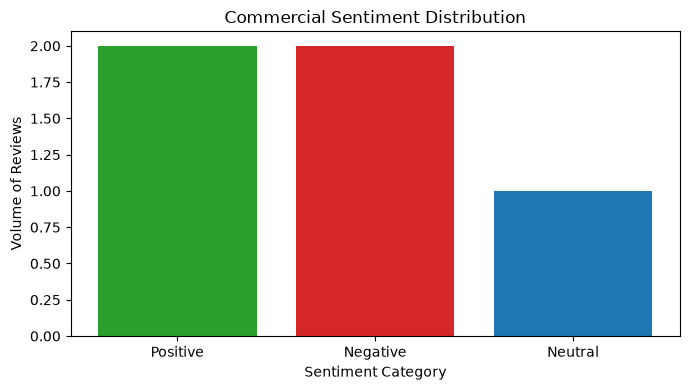

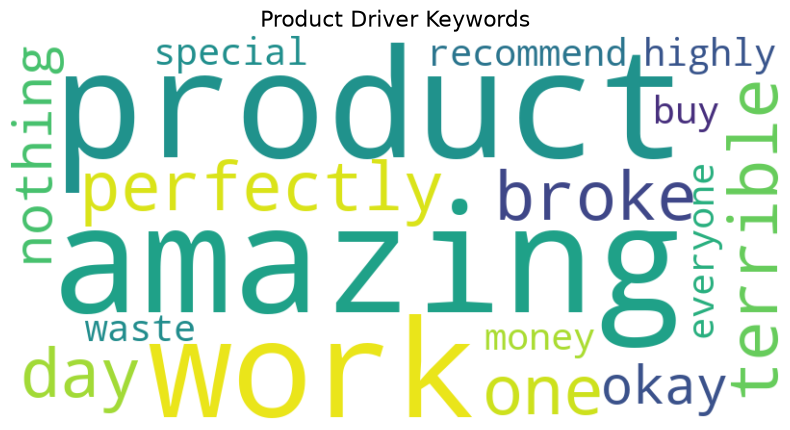

In [12]:
def generate_business_insights(df):
    """Generates commercial dashboards for sentiment distribution and key drivers."""
    sentiment_counts = df['Sentiment'].value_counts()

    # Dynamic colors to match however many sentiment classes exist
    color_map = {'Positive': '#2ca02c', 'Negative': '#d62728', 'Neutral': '#1f77b4'}
    bar_colors = [color_map.get(s, '#7f7f7f') for s in sentiment_counts.index]

    # 1. Distribution Bar Chart (matplotlib — avoids Plotly/nbformat version conflict)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors)
    ax.set_title('Commercial Sentiment Distribution')
    ax.set_xlabel('Sentiment Category')
    ax.set_ylabel('Volume of Reviews')
    plt.tight_layout()
    plt.show()

    # 2. Word Cloud for Actionable Feedback
    text_col = 'Cleaned_Review' if 'Cleaned_Review' in df.columns else 'Review'
    text_corpus = " ".join(df[text_col].dropna())

    if text_corpus.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_corpus)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Product Driver Keywords', fontsize=16)
        plt.show()
    else:
        print("Warning: No text available to generate word cloud.")

generate_business_insights(df_train)

Writing the application code directly from the notebook to an `app.py` file. This allows recruiters to instantly run `streamlit run app.py` and test the model interactively.


In [9]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import re
import requests
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import nltk
from bs4 import BeautifulSoup
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure required NLTK data is available
for resource in ['stopwords', 'punkt', 'punkt_tab', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)


# --- Helper functions (previously in analysis.py) ---

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+|\[.*?\]|[^a-zA-Z\s]+|\w*\d\w*', ' ', text)
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = nltk.word_tokenize(text)
    processed = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(processed)


def scrap_page(reviews_url):
    headers = {
        'authority': 'www.amazon.com',
        'accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8',
        'accept-language': 'en-US,en;q=0.9',
        'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/102.0.0.0 Safari/537.36'
    }
    response = requests.get(reviews_url, headers=headers)
    soup = BeautifulSoup(response.text, 'lxml')
    boxes = soup.select('div[data-hook="review"]')
    reviews = []
    for box in boxes:
        try:
            stars = box.select_one('[data-hook="review-star-rating"]').text.strip().split(' out')[0]
            title = box.select_one('[data-hook="review-title"]').text
            title = re.sub(r'\d.\d out of 5 stars', ' ', title).strip()
            description = box.select_one('[data-hook="review-body"]').text.strip()
            reviews.append({'Stars': float(stars), 'Review': title + ' ' + description})
        except Exception:
            continue
    return pd.DataFrame(reviews)


def fetch_live_reviews(url):
    pattern = r'(https:\/\/www\.amazon\.[a-z]+(\.[a-z]+)?\/[^\/]+)\/dp\/([^\/]+)\/?\??.*'
    match = re.match(pattern, url)
    if match:
        product_url, _, product_id = match.groups()
        reviews_url = f'{product_url}/product-reviews/{product_id}/'
        return scrap_page(reviews_url)
    else:
        raise ValueError('Invalid Amazon URL format')


# --- Streamlit App ---

# Load Artifacts
with open('models.p', 'rb') as mod:
    data = pickle.load(mod)
vect = data['vectorizer']

st.title('AI-Driven Sentiment Intelligence')
st.markdown('A robust NLP dashboard for real-time commercial product analysis.')

classifier = st.sidebar.radio('Select Classification Engine', ['Linear SVC (Recommended)', 'Logistic Regression'])
model = data['svm'] if 'SVC' in classifier else data['logreg']

st.subheader('1. Live Amazon Product Analysis')
url_review = st.text_input('Enter Amazon Product URL:')
if st.button('Scrape & Analyze Live Data'):
    with st.spinner('Extracting and processing live reviews...'):
        try:
            live_df = fetch_live_reviews(url_review)
            if live_df.empty:
                st.warning('No reviews found. Amazon may be blocking the scraper — try a different URL.')
            else:
                live_df['Cleaned'] = live_df['Review'].apply(preprocess_text)
                X_live = vect.transform(live_df['Cleaned'])
                live_df['Sentiment'] = model.predict(X_live)
                st.success(f'Successfully processed {len(live_df)} reviews.')
                col1, col2 = st.columns(2)
                with col1:
                    st.dataframe(live_df[['Stars', 'Sentiment', 'Review']].head(10))
                with col2:
                    sent_counts = live_df['Sentiment'].value_counts()
                    fig = go.Figure(data=[go.Pie(labels=sent_counts.index, values=sent_counts.values)])
                    st.plotly_chart(fig, use_container_width=True)
        except Exception as e:
            st.error(f'Error scraping URL: {e}')


Overwriting app.py
